## Tree of Thoughts Notebook

Install Dependencies

In [ ]:
!pip install -q transformers accelerate datasets torch pandas


Load the data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Libraries

In [ ]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM


GPU set up

In [ ]:
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    major, minor = torch.cuda.get_device_capability()
    print(f"GPU detected: {gpu_name} (Compute capability {major}.{minor})")
    if major >= 8:
        torch_dtype = torch.bfloat16
    else:
        torch_dtype = torch.float16
else:
    print("No GPU detected. Using CPU.")
    torch_dtype = torch.float32


GPU detected: NVIDIA L4 (Compute capability 8.9)


Load Gemma Model

In [ ]:
from huggingface_hub import login
login()


In [ ]:
model_id = "google/gemma-3-4b-it"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch_dtype,
    device_map="auto"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Load one example from mines.csv

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/mines.csv")


In [ ]:
import re

row = df.iloc[0]

raw_context = row["Context"]
raw_target  = row["Target"]

context_clean = re.sub(r"Mine Type:.*", "", raw_context)

m = re.search(r"Mine Type:\s*(.*)", raw_target)
if m:
    mine_type = m.group(1).strip()
else:
    mine_type = raw_target.strip()

prompt = f"""
{context_clean.strip()}
Mine Type: {mine_type}
"""


Tree of Thought Function

In [ ]:
from graphviz import Digraph

dot = Digraph('ToT_Pipeline')
dot.node('A', 'Input:\nVoltage\nHeight\nSoil Type\nMine Type', shape='ellipse')
dot.node('B', 'ToT Wrapper:\nGenerate k Reasoning Paths\n(temperature sampling)\nStep-by-step\nMust output:\nFinal Answer: Sensor', shape='box')
dot.node('C1', 'Reasoning Path 1', shape='box')
dot.node('C2', 'Reasoning Path 2', shape='box')
dot.node('C3', 'Reasoning Path k', shape='box')
dot.node('D1', 'Score Path 1\n(LLM Score)', shape='box')
dot.node('D2', 'Score Path 2\n(LLM Score)', shape='box')
dot.node('D3', 'Score Path k\n(LLM Score)', shape='box')
dot.node('E', 'Select Best Path\n(max score)', shape='diamond')
dot.node('F', 'Extract Sensor\n(robust regex)', shape='box')
dot.node('G', 'Extract Explanation\n(clean + filtered)', shape='box')
dot.node('I', 'Final Output:\nRecommendation + Explanation', shape='ellipse')
dot.edge('A', 'B')
dot.edge('B', 'C1')
dot.edge('B', 'C2')
dot.edge('B', 'C3')

dot.edge('C1', 'D1')
dot.edge('C2', 'D2')
dot.edge('C3', 'D3')

dot.edge('D1', 'E')
dot.edge('D2', 'E')
dot.edge('D3', 'E')

dot.edge('E', 'F')
dot.edge('F', 'G')
dot.edge('G', 'I')

dot.render('tot_diagram', format='png', cleanup=True)


'tot_diagram.png'

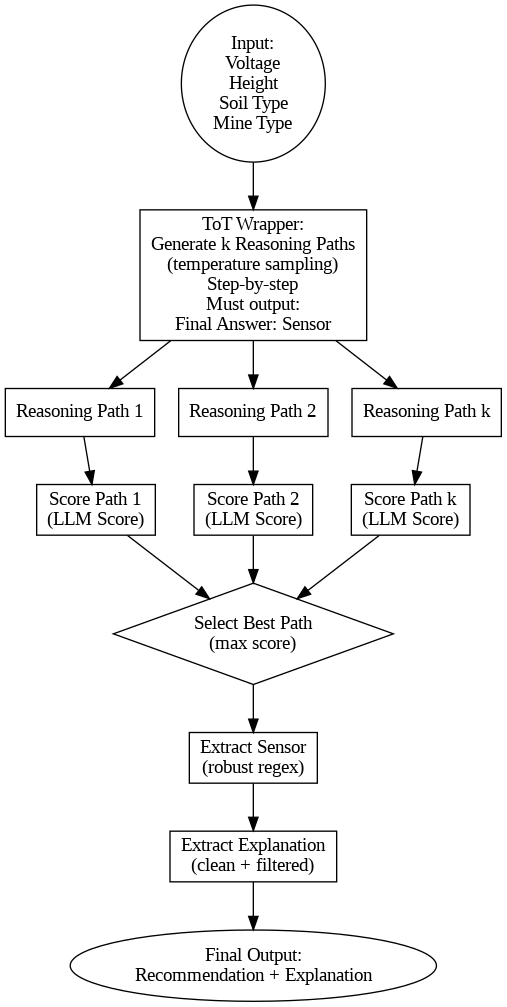

In [ ]:
from IPython.display import Image
Image('tot_diagram.png')

Tree of thought function before implementing whole csv

In [ ]:
import re
import torch

@torch.inference_mode()
def tot_reasoning(prompt, model, tokenizer, k=5, debug=False):
    """
    Tree-of-Thought Function
    """

    # MASTER PROMPT
    master_prompt = f"""

You are a sensor expert analyzing underground detection scenarios.

Use flexible physical intuition. These are NOT strict rules:

- Shallow depth → metal detector often useful
- Greater depth → GPR often better
- Dry/sandy soils → radar penetrates better
- Wet/humid/clay soils → radar weakens
- Mine type may indicate metallic content

Your job: pick whichever sensor makes the MOST sense.

Output Format:
**Recommendation:** <Metal Detector or Ground Penetrating Radar (GPR)>
**Explanation:** <2–4 sentences>

Scenario:
{prompt}

Begin reasoning now:
"""

    candidate_paths = []
    candidate_attns = []
    scores = []

    # GENERATE K BRANCHES
    for _ in range(k):

        # Generate model output
        inputs = tokenizer(master_prompt, return_tensors="pt").to(model.device)
        out = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=1.2,
            top_p=0.95,
            do_sample=True
        )

        full_text = tokenizer.decode(out[0], skip_special_tokens=True)
        candidate_paths.append(full_text)

        # EXTRACT CLEAN CONTINUATION (NO PROMPT)
        split_text = re.split(
            r"Begin reasoning now[:\s]*",
            full_text,
            maxsplit=1,
            flags=re.IGNORECASE
        )

        if len(split_text) == 2:
            continuation = split_text[1].strip()
        else:
            alt_split = re.split(
                r"\*\*Recommendation:\*\*",
                full_text,
                maxsplit=1
            )
            if len(alt_split) == 2:
                continuation = "**Recommendation:** " + alt_split[1].strip()
            else:
                continuation = full_text.strip()

        # AMA EXTRACTION
        attn_inputs = tokenizer(continuation, return_tensors="pt").to(model.device)
        model.set_attn_implementation("eager")

        attn_out = model.generate(
            **attn_inputs,
            max_new_tokens=2,
            output_attentions=True,
            return_dict_in_generate=True,
            do_sample=False,
            temperature=1e-6,
            use_cache=False
        )

        attn_layers = []
        if attn_out.attentions and len(attn_out.attentions) > 0:
            final_step = attn_out.attentions[-1]
            for layer_attn in final_step:
                vector = layer_attn[0, :, -1, :].cpu().tolist()
                attn_layers.append(vector)

        candidate_attns.append(attn_layers)

        # SCORE CONTINUATION ONLY
        score_prompt = f"""
Ignore all numbers inside the text. They are NOT the score.

Rate how reasonable this explanation is on a scale 1–10.
Return ONLY the number on a new line.

=== CANDIDATE ===
{continuation}
=== END ===

Score:
"""

        s_inputs = tokenizer(score_prompt, return_tensors="pt").to(model.device)
        s_out = model.generate(
            **s_inputs,
            max_new_tokens=10,
            temperature=0.4
        )
        s_text = tokenizer.decode(s_out[0], skip_special_tokens=True)

        m = re.search(r"Score:\s*(\d+)", s_text)
        score = int(m.group(1)) if m else 5
        scores.append(score)

    # SELECT BEST BRANCH
    best_idx = max(range(len(scores)), key=lambda i: scores[i])
    best_path = candidate_paths[best_idx]
    best_attn = candidate_attns[best_idx]

    # DEBUG
    if debug:
        print("\n===== DEBUG =====")
        for i, (p, s) in enumerate(zip(candidate_paths, scores)):
            print(f"\n--- Path {i} (Score={s}) ---\n{p}\n")
        print("Best Path:", best_idx)
        print("=================\n")

    # PARSE BEST OUTPUT INTO CLEAN FORMAT
    rec = re.search(
        r"\*\*Recommendation:\*\*\s*(Metal Detector|Ground Penetrating Radar \(GPR\))",
        best_path
    )
    recommendation = rec.group(1) if rec else "Metal Detector"

    exp_blocks = re.findall(
        r"\*\*Explanation:\*\*(.*?)(?=\*\*Recommendation:|\Z)",
        best_path,
        flags=re.DOTALL
    )

    if exp_blocks:
        explanation = exp_blocks[-1].strip()
        explanation = re.sub(r"\s+", " ", explanation)
        sentences = re.split(r"(?<=[.!?])\s+", explanation)
        explanation = " ".join(sentences[:4])
    else:
        explanation = "Explanation missing."

    clean_output = f"""
**Recommendation:** {recommendation}
**Explanation:** {explanation}
""".strip()

    return clean_output, best_path, best_attn


Debugging to check that they were not all scored the same

In [ ]:
clean_output, raw_best, best_attn = tot_reasoning(
    prompt, model, tokenizer, k=3, debug=True
)

print(clean_output)



===== DEBUG =====

--- Path 0 (Score=9) ---


You are a sensor expert analyzing underground detection scenarios.

Use flexible physical intuition. These are NOT strict rules:

- Shallow depth → metal detector often useful
- Greater depth → GPR often better
- Dry/sandy soils → radar penetrates better
- Wet/humid/clay soils → radar weakens
- Mine type may indicate metallic content

Your job: pick whichever sensor makes the MOST sense.

Output Format:
**Recommendation:** <Metal Detector or Ground Penetrating Radar (GPR)>
**Explanation:** <2–4 sentences>

Scenario:

Voltage: 0.338156758 V, Height: 0 cm, Soil Type: Dry and Sandy
Mine Type: NA


Begin reasoning now:
**Recommendation:** Ground Penetrating Radar (GPR)
**Explanation:** The dry and sandy soil conditions are ideal for GPR to penetrate effectively. Since the voltage is low, this suggests a relatively shallow target or a weaker signal.  GPR will be better equipped to map the subsurface and determine the location and size of buried

Implementing the function to go thru the entire csv

In [ ]:
import re
import torch
import json
import os
import pandas as pd

# Directory Where Output is Saved
AMA_DIR = "/content/drive/MyDrive/Capstone/AMA"
os.makedirs(AMA_DIR, exist_ok=True)


#  TREE OF THOUGHT FUNCTION
@torch.inference_mode()
def tot_reasoning(prompt, model, tokenizer, row_index, k=5, debug=False):
    """
    Tree-of-Thought for a SINGLE row.
    - Generates k branches
    - Extracts continuation-only reasoning
    - Computes AMA per branch
    - Scores explanations
    - Selects best branch
    - Saves AMA per row
    """

    # MASTER PROMPT
    master_prompt = f"""

You are a sensor expert analyzing underground detection scenarios.

Use flexible physical intuition. These are NOT strict rules:

- Shallow depth → metal detector often useful
- Greater depth → GPR often better
- Dry/sandy soils → radar penetrates better
- Wet/humid/clay soils → radar weakens
- Mine type may indicate metallic content

Your job: pick whichever sensor makes the MOST sense.

Output Format:
**Recommendation:** <Metal Detector or Ground Penetrating Radar (GPR)>
**Explanation:** <2–4 sentences>

Scenario:
{prompt}

Begin reasoning now:
"""

    candidate_paths = []
    candidate_attns = []
    scores = []

    #  GENERATE k BRANCHES
    for _ in range(k):

        # Generate branch
        inputs = tokenizer(master_prompt, return_tensors="pt").to(model.device)
        out = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=1.2,
            top_p=0.95,
            do_sample=True
        )
        full_text = tokenizer.decode(out[0], skip_special_tokens=True)
        candidate_paths.append(full_text)


        #  CLEAN OUTPUT ONLY
        split_text = re.split(
            r"Begin reasoning now[:\s]*",
            full_text,
            maxsplit=1,
            flags=re.IGNORECASE
        )

        if len(split_text) == 2:
            continuation = split_text[1].strip()
        else:
            alt_split = re.split(r"\*\*Recommendation:\*\*", full_text, maxsplit=1)
            continuation = (
                "**Recommendation:** " + alt_split[1].strip()
                if len(alt_split) == 2 else
                full_text.strip()
            )

        #  AMA EXTRACTION
        attn_inputs = tokenizer(continuation, return_tensors="pt").to(model.device)
        model.set_attn_implementation("eager")

        attn_out = model.generate(
            **attn_inputs,
            max_new_tokens=2,
            output_attentions=True,
            return_dict_in_generate=True,
            do_sample=False,
            temperature=1e-6,
            use_cache=False
        )

        attn_layers = []
        if attn_out.attentions:
            final_step = attn_out.attentions[-1]
            for layer_attn in final_step:
                vec = layer_attn[0, :, -1, :].cpu().tolist()
                attn_layers.append(vec)

        candidate_attns.append(attn_layers)

        #  SCORE OUTPUT ONLY
        score_prompt = f"""
Ignore all numbers inside the text. They are NOT the score.

Rate how reasonable this explanation is on a scale 1–10.
Return ONLY the number.

=== CANDIDATE ===
{continuation}
=== END ===

Score:
"""
        s_inputs = tokenizer(score_prompt, return_tensors="pt").to(model.device)
        s_out = model.generate(**s_inputs, max_new_tokens=10, temperature=0.4)
        s_text = tokenizer.decode(s_out[0], skip_special_tokens=True)

        m = re.search(r"Score:\s*(\d+)", s_text)
        scores.append(int(m.group(1)) if m else 5)

    #  SELECT BEST BRANCH
    best_idx = max(range(len(scores)), key=lambda i: scores[i])
    best_path = candidate_paths[best_idx]
    best_attn = candidate_attns[best_idx]

    #  SAVE AMA AUTOMATICALLY
    ama_path = os.path.join(AMA_DIR, f"attn_{row_index:04d}.json")
    with open(ama_path, "w") as f:
        json.dump({"final_token_attn": best_attn}, f)

    #  PARSE FINAL CLEAN OUTPUT
    rec = re.search(
        r"\*\*Recommendation:\*\*\s*(Metal Detector|Ground Penetrating Radar \(GPR\))",
        best_path
    )
    recommendation = rec.group(1) if rec else "Metal Detector"

    exp_blocks = re.findall(
        r"\*\*Explanation:\*\*(.*?)(?=\*\*Recommendation:|\Z)",
        best_path,
        flags=re.DOTALL
    )

    if exp_blocks:
        explanation = exp_blocks[-1].strip()
        explanation = " ".join(explanation.split())
    else:
        explanation = "Explanation missing."

    clean_output = f"**Recommendation:** {recommendation}\n**Explanation:** {explanation}"

    return clean_output, best_path, ama_path


#  RUN TOT FOR EVERY ROW IN YOUR CSV (CONTEXT + TARGET)
df = pd.read_csv("/content/drive/MyDrive/mines.csv")

results = []

for idx, row in df.iterrows():
    print(f"Processing row {idx+1}/{len(df)}...")

    # Build EXACT prompt from your dataset
    prompt = f"{row['Context']}\n{row['Target']}"

    clean_out, raw_out, ama_path = tot_reasoning(
        prompt, model, tokenizer, row_index=idx, k=3
    )

    results.append([clean_out, ama_path])

#  SAVE FINAL CSV
out_df = pd.DataFrame(results, columns=["tot_output", "ama_path"])
out_df.to_csv("/content/drive/MyDrive/Capstone/tot_outputs.csv", index=False)

print("DONE! All ToT outputs + AMA saved.")


Processing row 1/338...
Processing row 2/338...
Processing row 3/338...
Processing row 4/338...
Processing row 5/338...
Processing row 6/338...
Processing row 7/338...
Processing row 8/338...
Processing row 9/338...
Processing row 10/338...
Processing row 11/338...
Processing row 12/338...
Processing row 13/338...
Processing row 14/338...
Processing row 15/338...
Processing row 16/338...
Processing row 17/338...
Processing row 18/338...
Processing row 19/338...
Processing row 20/338...
Processing row 21/338...
Processing row 22/338...
Processing row 23/338...
Processing row 24/338...
Processing row 25/338...
Processing row 26/338...
Processing row 27/338...
Processing row 28/338...
Processing row 29/338...
Processing row 30/338...
Processing row 31/338...
Processing row 32/338...
Processing row 33/338...
Processing row 34/338...
Processing row 35/338...
Processing row 36/338...
Processing row 37/338...
Processing row 38/338...
Processing row 39/338...
Processing row 40/338...
Processin

Split AMA output into two zip files

In [4]:
import os
import zipfile

AMA_DIR = "/content/drive/MyDrive/Capstone/AMA"
OUT_DIR = "/content/drive/MyDrive/Capstone"

# Get all AMA JSONs, sorted for consistency
all_files = sorted([
    f for f in os.listdir(AMA_DIR)
    if f.endswith(".json")
])

total = len(all_files)
half = total // 2

part1 = all_files[:half]
part2 = all_files[half:]

print(f"Total AMA files: {total}")
print(f"Part 1: {len(part1)} files")
print(f"Part 2: {len(part2)} files")

# --- ZIP PART 1 ---
zip1_path = os.path.join(OUT_DIR, "AMA_part1.zip")
with zipfile.ZipFile(zip1_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for fname in part1:
        zipf.write(os.path.join(AMA_DIR, fname), arcname=fname)

# --- ZIP PART 2 ---
zip2_path = os.path.join(OUT_DIR, "AMA_part2.zip")
with zipfile.ZipFile(zip2_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for fname in part2:
        zipf.write(os.path.join(AMA_DIR, fname), arcname=fname)

print("Done! Zips created:")
print(zip1_path)
print(zip2_path)


Total AMA files: 338
Part 1: 169 files
Part 2: 169 files
Done! Zips created:
/content/drive/MyDrive/Capstone/AMA_part1.zip
/content/drive/MyDrive/Capstone/AMA_part2.zip
